In [5]:
!pip3 install numpy matplotlib control sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 50.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 35.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sympy]32m1/2 [sympy]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import control
import sympy as sp

In [8]:
# Transfer Function: H(s) = x2(s) / F(s)
# Resulting from the derivation: H(s) = (s + 1) / (s^4 + 5s^3 + 7s^2 + 4s - 1)

# Define the coefficients for the transfer function (descending powers of s)
num = [1, 1]
den = [1, 5, 7, 4, -1]

In [9]:
# 1. Define Symbolic Transfer Function for verification
s_sym = sp.symbols('s')
tf_sym = (s_sym + 1) / (s_sym**4 + 5*s_sym**3 + 7*s_sym**2 + 4*s_sym - 1)
print("Symbolic representation of H(s):")
print(tf_sym)

Symbolic representation of H(s):
(s + 1)/(s**4 + 5*s**3 + 7*s**2 + 4*s - 1)


In [10]:
# 2. Create the control.tf system object
system = control.tf(num, den)
print("\nControl Object Transfer Function:")
print(system)


Control Object Transfer Function:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              s + 1
  -----------------------------
  s^4 + 5 s^3 + 7 s^2 + 4 s - 1


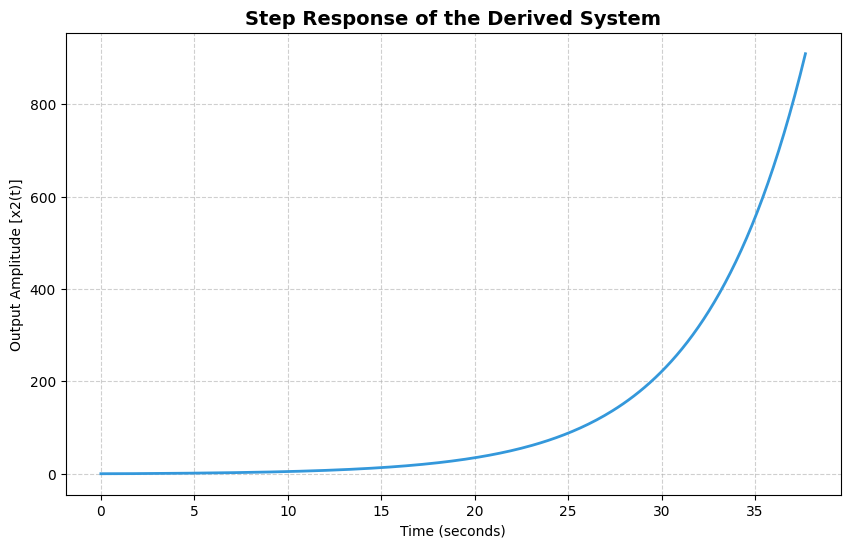

In [11]:
# 3. Visualization: Step Response Plot
plt.figure(figsize=(10, 6))
time, response = control.step_response(system)
plt.plot(time, response, color='#3498DB', linewidth=2)
plt.title('Step Response of the Derived System', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Output Amplitude [x2(t)]')
plt.grid(True, which='both', linestyle='--', alpha=0.6)


Text(0.5, 0.98, 'Bode Plot: Magnitude and Phase')

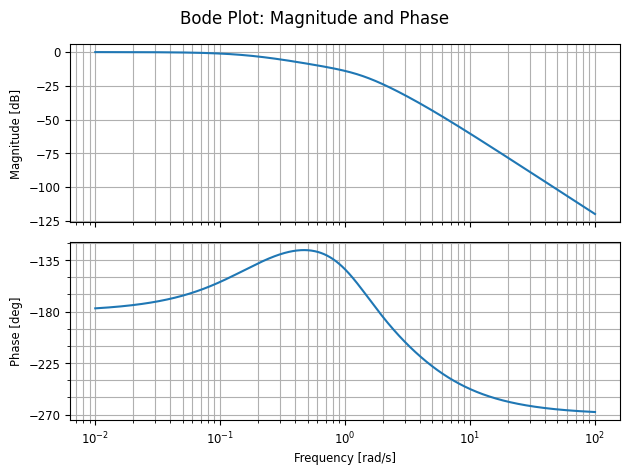

In [12]:
# 4. Visualization: Bode Plot
plt.figure()
control.bode_plot(system, dB=True, Hz=False, grid=True)
plt.suptitle('Bode Plot: Magnitude and Phase')

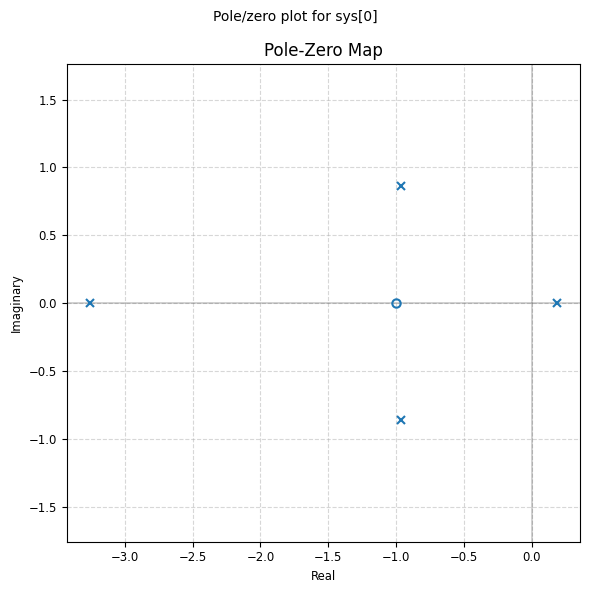

In [13]:
# 5. Visualization: Pole-Zero Map
plt.figure(figsize=(6, 6))
control.pole_zero_plot(system)
plt.title('Pole-Zero Map')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()